In [1]:

# ============================================
# CUSTOMER LIFETIME VALUE CALCULATION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("CLV calculation notebook started.")

# Load the prepared survival dataset
data_path = "../data/processed/eda_dataset.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
display(df.head())
print("Available columns:")
print(df.columns.tolist())

CLV calculation notebook started.
Dataset shape: (50000, 16)


,customer_id,starting_date,suspension_date,observation_end_date,duration_days,event,age,income,annual_premium,has_children,marital_status,home_owner,college_degree,good_credit,county,duration_years
0,2.213007e+11,2022-09-02,2022-09-18,2022-09-18,16,1,42.806,250000.0,756.722144,1.0,Married,1.0,0.0,1.0,Tarrant,0.043806
1,2.213033e+11,2009-09-13,NaN,2022-12-02,4828,0,47.305,125000.0,875.814547,0.0,Married,1.0,1.0,1.0,Tarrant,13.218344
2,2.213023e+11,2018-02-15,NaN,2022-12-02,1751,0,41.892,70000.0,654.552197,1.0,Single,1.0,1.0,1.0,Collin,4.793977
3,2.213030e+11,2016-10-24,NaN,2022-12-02,2230,0,58.639,42500.0,795.654884,0.0,Single,1.0,0.0,1.0,Tarrant,6.105407
4,2.213006e+11,2022-06-24,2022-11-30,2022-11-30,159,1,55.444,125000.0,1142.303520,0.0,Unknown,0.0,0.0,1.0,Denton,0.435318


Available columns:
['customer_id', 'starting_date', 'suspension_date', 'observation_end_date', 'duration_days', 'event', 'age', 'income', 'annual_premium', 'has_children', 'marital_status', 'home_owner', 'college_degree', 'good_credit', 'county', 'duration_years']


In [2]:

# ============================================
# STEP 8: PREPARE DATA FOR CLV CALCULATION
# ============================================

print("Preparing data for CLV calculation...")

# Select the required columns
clv_df = df[
    [
        "customer_id",
        "duration_years",
        "event",
        "annual_premium"
    ]
].copy()

# Check missing values
print("\nMissing values before handling:")
print(clv_df.isnull().sum())

# Validate important columns
print("\nEvent values:")
print(sorted(clv_df["event"].unique()))

print("\nDuration statistics:")
print(clv_df["duration_years"].describe())

print("\nAnnual premium statistics:")
print(clv_df["annual_premium"].describe())

# Remove rows with missing values in required columns
clv_df = clv_df.dropna(
    subset=[
        "duration_years",
        "event",
        "annual_premium"
    ]
).copy()

# Ensure numeric data types
clv_df["duration_years"] = pd.to_numeric(
    clv_df["duration_years"],
    errors="coerce"
)

clv_df["annual_premium"] = pd.to_numeric(
    clv_df["annual_premium"],
    errors="coerce"
)

clv_df["event"] = pd.to_numeric(
    clv_df["event"],
    errors="coerce"
)

# Remove invalid values
clv_df = clv_df[
    (clv_df["duration_years"] > 0) &
    (clv_df["annual_premium"] >= 0) &
    (clv_df["event"].isin([0, 1]))
].copy()

# Reset index
clv_df.reset_index(drop=True, inplace=True)

print("\nPrepared CLV dataset shape:", clv_df.shape)

print("\nMissing values after handling:")
print(clv_df.isnull().sum())

display(clv_df.head())

Preparing data for CLV calculation...

Missing values before handling:
customer_id       0
duration_years    0
event             0
annual_premium    0
dtype: int64

Event values:
[np.int64(0), np.int64(1)]

Duration statistics:
count    50000.000000
mean         9.839588
std          6.195284
min          0.002738
25%          4.087611
50%          9.894593
75%         17.223819
max         17.223819
Name: duration_years, dtype: float64

Annual premium statistics:
count    50000.000000
mean       929.963783
std        243.676858
min         31.686521
25%        763.106360
50%        924.241777
75%       1089.495688
max       2197.304870
Name: annual_premium, dtype: float64

Prepared CLV dataset shape: (50000, 4)

Missing values after handling:
customer_id       0
duration_years    0
event             0
annual_premium    0
dtype: int64


,customer_id,duration_years,event,annual_premium
0,2.213007e+11,0.043806,1,756.722144
1,2.213033e+11,13.218344,0,875.814547
2,2.213023e+11,4.793977,0,654.552197
3,2.213030e+11,6.105407,0,795.654884
4,2.213006e+11,0.435318,1,1142.303520


In [3]:

# ============================================
# STEP 9: OBSERVED PREMIUM-BASED VALUE
# ============================================

print("Calculating observed premium-based value...")

# Calculate observed premium-based value
clv_df["observed_premium_value"] = (
    clv_df["annual_premium"] *
    clv_df["duration_years"]
)

# Separate event and non-event customers
event_customers = clv_df[clv_df["event"] == 1]
non_event_customers = clv_df[clv_df["event"] == 0]

print(
    "Customers with event = 1:",
    len(event_customers)
)

print(
    "Customers with event = 0:",
    len(non_event_customers)
)

# Display value statistics
print("\nObserved premium-based value statistics:")
display(
    clv_df["observed_premium_value"].describe()
)

# Display sample results
display(
    clv_df[
        [
            "customer_id",
            "duration_years",
            "event",
            "annual_premium",
            "observed_premium_value"
        ]
    ].head(10)
)

Calculating observed premium-based value...
Customers with event = 1: 4184
Customers with event = 0: 45816

Observed premium-based value statistics:


count    50000.000000
mean      9194.791504
std       6642.522371
min          1.986291
25%       3488.142771
50%       8175.715872
75%      14356.980195
max      36838.676378
Name: observed_premium_value, dtype: float64

,customer_id,duration_years,event,annual_premium,observed_premium_value
0,2.213007e+11,0.043806,1,756.722144,33.148677
1,2.213033e+11,13.218344,0,875.814547,11576.817612
2,2.213023e+11,4.793977,0,654.552197,3137.908000
3,2.213030e+11,6.105407,0,795.654884,4857.797101
4,2.213006e+11,0.435318,1,1142.303520,497.265598
5,2.213005e+11,4.906229,0,941.240407,4617.940614
6,2.213029e+11,11.811088,0,905.005388,10689.098546
7,2.213020e+11,5.768652,0,631.197970,3641.161185
8,2.213007e+11,0.596851,0,739.745396,441.518128
9,2.213008e+11,6.595483,0,512.480847,3380.058482


Fitting Kaplan-Meier survival model...
Kaplan-Meier model fitted successfully.


,KM_estimate
timeline,
0.000000,1.00000
0.002738,0.99980
0.005476,0.99970
0.008214,0.99960
0.010951,0.99944


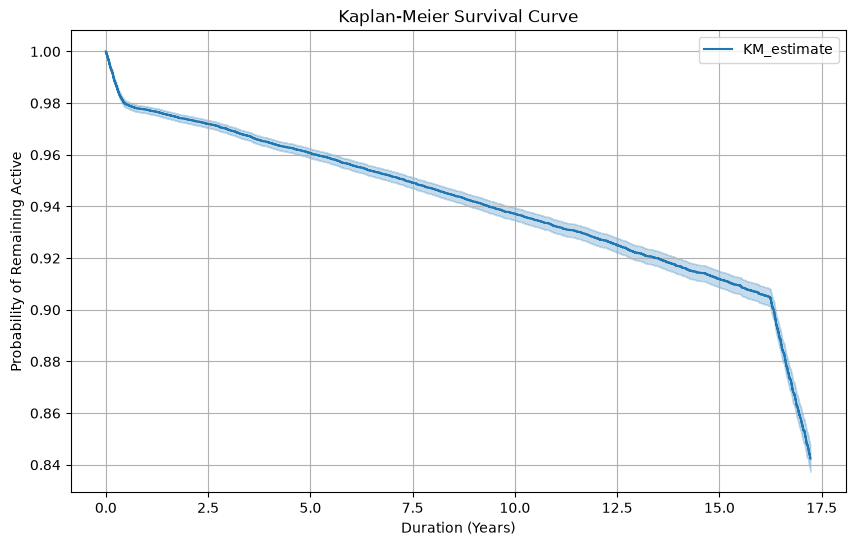

In [4]:

# ============================================
# STEP 10: KAPLAN-MEIER SURVIVAL-BASED VALUE
# ============================================

from lifelines import KaplanMeierFitter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Fitting Kaplan-Meier survival model...")

# Create Kaplan-Meier model
kmf = KaplanMeierFitter()

kmf.fit(
    durations=clv_df["duration_years"],
    event_observed=clv_df["event"]
)

print("Kaplan-Meier model fitted successfully.")

# Display survival table
display(kmf.survival_function_.head())

# Plot survival curve
plt.figure(figsize=(10, 6))

kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Duration (Years)")
plt.ylabel("Probability of Remaining Active")
plt.grid(True)
plt.show()

In [5]:

# ============================================
# STEP 11: EXPECTED SURVIVAL YEARS
# ============================================

print("Calculating expected survival years...")

# Planning horizon
planning_horizon = 10

# Year points from 0 to 10
year_points = np.arange(
    0,
    planning_horizon + 1,
    1
)

# Estimate survival probabilities at each year
survival_probabilities = kmf.predict(
    year_points
).to_numpy()

# Display survival probabilities
survival_table = pd.DataFrame({
    "year": year_points,
    "survival_probability": survival_probabilities
})

display(survival_table)

# Calculate expected survival years using trapezoidal integration
expected_survival_years = np.trapezoid(
    survival_probabilities,
    year_points
)

print(
    "Expected survival years over",
    planning_horizon,
    "years:",
    round(expected_survival_years, 4)
)

Calculating expected survival years...


,year,survival_probability
0,0,1.000000
1,1,0.977471
2,2,0.973667
3,3,0.969718
4,4,0.964720
5,5,0.960670
6,6,0.956061
7,7,0.951576
8,8,0.946833
9,9,0.941854


Expected survival years over 10 years: 9.6112


In [6]:

# ============================================
# STEP 12: SURVIVAL-ADJUSTED PREMIUM VALUE
# ============================================

print("Calculating survival-adjusted premium value...")

# Calculate survival-adjusted value
clv_df["survival_adjusted_value"] = (
    clv_df["annual_premium"] *
    expected_survival_years
)

# Display summary statistics
print("\nSurvival-adjusted value statistics:")

display(
    clv_df["survival_adjusted_value"].describe()
)

# Display sample customer values
display(
    clv_df[
        [
            "customer_id",
            "annual_premium",
            "duration_years",
            "event",
            "observed_premium_value",
            "survival_adjusted_value"
        ]
    ].head(10)
)

Calculating survival-adjusted premium value...

Survival-adjusted value statistics:


count    50000.000000
mean      8938.059038
std       2342.024694
min        304.545188
25%       7334.360567
50%       8883.063747
75%      10471.350557
max      21118.715597
Name: survival_adjusted_value, dtype: float64

,customer_id,annual_premium,duration_years,event,observed_premium_value,survival_adjusted_value
0,2.213007e+11,756.722144,0.043806,1,33.148677,7273.000649
1,2.213033e+11,875.814547,13.218344,0,11576.817612,8417.620416
2,2.213023e+11,654.552197,4.793977,0,3137.908000,6291.025829
3,2.213030e+11,795.654884,6.105407,0,4857.797101,7647.190628
4,2.213006e+11,1142.303520,0.435318,1,497.265598,10978.896690
5,2.213005e+11,941.240407,4.906229,0,4617.940614,9046.440817
6,2.213029e+11,905.005388,11.811088,0,10689.098546,8698.179149
7,2.213020e+11,631.197970,5.768652,0,3641.161185,6066.563906
8,2.213007e+11,739.745396,0.596851,0,441.518128,7109.833891
9,2.213008e+11,512.480847,6.595483,0,3380.058482,4925.551026
